# Forecasting USD/AUD Exchange Rates with ARIMA and Exponential Smoothing

**Objective:** Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data in `exchange_rate.csv` (daily USD → Australian Dollar rate, 1 January 1990 to 10 October 2010).

**Notebook structure:**
- **Part 1 — Data Preparation and Exploration**
- **Part 2 — Model Building: ARIMA**
- **Part 3 — Evaluation and Comparison**

## A Note on Methodology

This environment does not have the `statsmodels` package available (no internet access to install it). Rather than skip the relevant techniques, **every statistical method used in this notebook — ACF/PACF, the Augmented Dickey-Fuller test, ARIMA estimation, the Ljung-Box test, and Holt's Exponential Smoothing — is implemented from first principles using NumPy/SciPy**, and each is validated against a known synthetic case (e.g., a simulated AR(1) process, a simulated random walk) before being applied to the real exchange rate data. This is slightly more code than a one-line `statsmodels` call, but it keeps every calculation fully transparent.

## Setup: Imports and Helper Functions

In [1]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

plt.rcParams["figure.dpi"] = 100
np.random.seed(42)  # for reproducibility of any randomized steps (e.g. optimizer restarts)

In [2]:
# --- Autocorrelation Function (ACF) ---
def acf(x, nlags):
    """Sample autocorrelation function at lags 0..nlags."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    x = x - x.mean()
    var = np.dot(x, x) / n
    result = np.empty(nlags + 1)
    for k in range(nlags + 1):
        cov = np.dot(x[:n - k], x[k:]) / n
        result[k] = cov / var
    return result


# --- Partial Autocorrelation Function (PACF) via Durbin-Levinson recursion ---
def pacf(x, nlags):
    """Partial autocorrelation function at lags 0..nlags, via Durbin-Levinson recursion."""
    r = acf(x, nlags)
    pacf_vals = np.zeros(nlags + 1)
    pacf_vals[0] = 1.0
    phi = np.zeros((nlags + 1, nlags + 1))
    if nlags >= 1:
        phi[1, 1] = r[1]
        pacf_vals[1] = r[1]
    for k in range(2, nlags + 1):
        num = r[k] - sum(phi[k-1, j] * r[k-j] for j in range(1, k))
        den = 1 - sum(phi[k-1, j] * r[j] for j in range(1, k))
        phi[k, k] = num / den
        for j in range(1, k):
            phi[k, j] = phi[k-1, j] - phi[k, k] * phi[k-1, k-j]
        pacf_vals[k] = phi[k, k]
    return pacf_vals


def plot_acf_pacf(series, nlags, title_suffix=""):
    """Plot ACF and PACF side by side (lags 1..nlags -- lag 0 is always exactly 1
    and isn't informative for order selection, so it's excluded to keep the
    y-axis scaled to the range that actually matters), with a 95% confidence band."""
    a = acf(series, nlags)
    p = pacf(series, nlags)
    n = len(series)
    ci = 1.96 / np.sqrt(n)
    lags = range(1, nlags + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, vals, name in zip(axes, [a, p], ["ACF", "PACF"]):
        ax.bar(lags, vals[1:], width=0.3, color="#4C72B0")
        ax.axhspan(-ci, ci, color="gray", alpha=0.2, label="95% CI (white noise)")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"{name}{title_suffix}")
        ax.set_xlabel("Lag")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

In [3]:
# --- Augmented Dickey-Fuller (ADF) test for a unit root ---
def adf_test(x, max_lag=10):
    """
    Augmented Dickey-Fuller test (regression with a constant, no trend term):
        delta_y_t = alpha + gamma*y_{t-1} + sum(delta_i * delta_y_{t-i}) + eps_t
    The lag order is chosen by minimizing AIC over 0..max_lag.
    H0: gamma = 0 (series has a unit root / is non-stationary).
    Critical values are the standard asymptotic MacKinnon values for this specification.
    """
    x = np.asarray(x, dtype=float)
    dy = np.diff(x)
    n_full = len(dy)

    best_aic, best_result = np.inf, None
    for lag in range(0, max_lag + 1):
        n = n_full - lag
        y_lag1 = x[lag: lag + n]
        dy_dep = dy[lag:]
        cols = [np.ones(n), y_lag1] + [dy[lag - i: lag - i + n] for i in range(1, lag + 1)]
        X = np.column_stack(cols)

        beta, _, _, _ = np.linalg.lstsq(X, dy_dep, rcond=None)
        resid = dy_dep - X @ beta
        rss = np.dot(resid, resid)
        k = X.shape[1]
        aic = n * np.log(rss / n) + 2 * k

        if aic < best_aic:
            sigma2 = rss / (n - k)
            se_gamma = np.sqrt(sigma2 * np.linalg.inv(X.T @ X)[1, 1])
            best_aic = aic
            best_result = {"lag": lag, "t_stat": beta[1] / se_gamma, "n_obs": n}

    best_result["critical_values"] = {"1%": -3.43, "5%": -2.86, "10%": -2.57}
    return best_result

In [4]:
# --- ARIMA(p, d, q) via Conditional Sum of Squares (CSS) estimation ---
class SimpleARIMA:
    """
    A from-scratch ARIMA(p, d, q). After differencing d times to get w_t:
        w_t = c + sum_i phi_i * w_{t-i} + sum_j theta_j * e_{t-j} + e_t
    Parameters are found by minimizing the sum of squared one-step residuals
    (Conditional Sum of Squares), using several random optimizer restarts for robustness.
    """

    def __init__(self, order):
        self.p, self.d, self.q = order

    def _difference(self, y, d):
        w = np.asarray(y, dtype=float)
        for _ in range(d):
            w = np.diff(w)
        return w

    def _css_residuals(self, params, w):
        p, q = self.p, self.q
        c = params[0]
        phi = params[1:1 + p]
        theta = params[1 + p:1 + p + q]
        n = len(w)
        e = np.zeros(n)
        for t in range(n):
            ar_part = sum(phi[i] * w[t - i - 1] for i in range(p) if t - i - 1 >= 0)
            ma_part = sum(theta[j] * e[t - j - 1] for j in range(q) if t - j - 1 >= 0)
            e[t] = w[t] - c - ar_part - ma_part
        return e

    def fit(self, y, n_restarts=3, seed=0):
        self.y_ = np.asarray(y, dtype=float)
        self.w_ = self._difference(self.y_, self.d)
        n_params = 1 + self.p + self.q

        def sse(params):
            e = self._css_residuals(params, self.w_)
            return np.sum(e ** 2)

        rng = np.random.default_rng(seed)
        starts = [np.zeros(n_params)] + [rng.uniform(-0.3, 0.3, n_params) for _ in range(n_restarts - 1)]

        best = None
        for x0 in starts:
            res = minimize(sse, x0, method="Nelder-Mead",
                            options={"maxiter": 5000, "xatol": 1e-8, "fatol": 1e-10})
            if best is None or res.fun < best.fun:
                best = res

        self.params_ = best.x
        self.sse_ = best.fun
        self.c_ = self.params_[0]
        self.phi_ = self.params_[1:1 + self.p]
        self.theta_ = self.params_[1 + self.p:1 + self.p + self.q]
        self.resid_ = self._css_residuals(self.params_, self.w_)

        n = len(self.w_)
        self.aic_ = n * np.log(self.sse_ / n) + 2 * n_params  # AIC-like model comparison score
        return self

    def forecast(self, steps):
        p, q, d = self.p, self.q, self.d
        w, e = list(self.w_), list(self.resid_)
        w_forecast = []
        for _ in range(steps):
            t = len(w)
            ar_part = sum(self.phi_[i] * w[t - i - 1] for i in range(p) if t - i - 1 >= 0)
            ma_part = sum(self.theta_[j] * e[t - j - 1] for j in range(q) if 0 <= t - j - 1 < len(e))
            w_hat = self.c_ + ar_part + ma_part
            w.append(w_hat); e.append(0.0)
            w_forecast.append(w_hat)
        w_forecast = np.array(w_forecast)
        if d == 0:
            return w_forecast
        elif d == 1:
            return self.y_[-1] + np.cumsum(w_forecast)
        else:
            raise NotImplementedError("Only d=0 or d=1 supported")

In [5]:
# --- Ljung-Box test for residual autocorrelation ---
def ljung_box_test(residuals, lags=10, n_params_fitted=0):
    """
    H0: residuals are white noise (no remaining autocorrelation up to `lags`).
    Degrees of freedom are reduced by the number of ARMA parameters already fitted,
    following standard practice.
    """
    n = len(residuals)
    r = acf(residuals, lags)
    Q = n * (n + 2) * sum((r[k] ** 2) / (n - k) for k in range(1, lags + 1))
    dof = max(lags - n_params_fitted, 1)
    p_value = stats.chi2.sf(Q, df=dof)
    return Q, p_value, dof

In [6]:
# --- Holt's Linear (double) Exponential Smoothing: level + trend, no seasonality ---
class HoltLinear:
    """
    level_t = alpha*y_t + (1-alpha)*(level_{t-1} + trend_{t-1})
    trend_t = beta*(level_t - level_{t-1}) + (1-beta)*trend_{t-1}
    alpha, beta are optimized by minimizing in-sample one-step-ahead SSE
    (mirrors how statsmodels' ExponentialSmoothing(optimized=True) works).
    """

    def _run(self, y, alpha, beta):
        n = len(y)
        level, trend, fitted = np.zeros(n), np.zeros(n), np.zeros(n)
        level[0] = y[0]
        trend[0] = y[1] - y[0] if n > 1 else 0.0
        fitted[0] = level[0]
        for t in range(1, n):
            fitted[t] = level[t-1] + trend[t-1]
            level[t] = alpha * y[t] + (1 - alpha) * (level[t-1] + trend[t-1])
            trend[t] = beta * (level[t] - level[t-1]) + (1 - beta) * trend[t-1]
        return level, trend, fitted

    def fit(self, y):
        self.y_ = np.asarray(y, dtype=float)

        def sse(params):
            alpha, beta = params
            if not (0 < alpha < 1 and 0 < beta < 1):
                return 1e18
            _, _, fitted = self._run(self.y_, alpha, beta)
            return np.sum((self.y_[1:] - fitted[1:]) ** 2)

        result = minimize(sse, x0=[0.3, 0.1], method="Nelder-Mead", options={"maxiter": 2000})
        self.alpha_, self.beta_ = result.x
        self.level_, self.trend_, self.fitted_ = self._run(self.y_, self.alpha_, self.beta_)
        self.resid_ = self.y_[1:] - self.fitted_[1:]
        return self

    def forecast(self, steps):
        last_level, last_trend = self.level_[-1], self.trend_[-1]
        return np.array([last_level + h * last_trend for h in range(1, steps + 1)])

### Validating the Helper Functions

Before trusting these from-scratch implementations on real data, we check each one against a synthetic case where the "right answer" is known.

In [7]:
# Validation 1: ACF/PACF on a simulated AR(1) process (phi=0.7) should show
# ACF decaying geometrically and PACF cutting off sharply after lag 1.
np.random.seed(1)
n_sim = 3000
eps = np.random.normal(0, 1, n_sim)
y_ar1 = np.zeros(n_sim)
for t in range(1, n_sim):
    y_ar1[t] = 0.7 * y_ar1[t-1] + eps[t]

print("Simulated AR(1), phi=0.7:")
print("  ACF lags 1-5: ", np.round(acf(y_ar1, 5)[1:], 3), " (expect geometric decay ~0.7, 0.49, ...)")
print("  PACF lags 1-5:", np.round(pacf(y_ar1, 5)[1:], 3), " (expect ~0.7 then near 0)")

Simulated AR(1), phi=0.7:
  ACF lags 1-5:  [0.69  0.481 0.334 0.233 0.155]  (expect geometric decay ~0.7, 0.49, ...)
  PACF lags 1-5: [ 0.69   0.008 -0.002  0.003 -0.016]  (expect ~0.7 then near 0)


In [8]:
# Validation 2: ADF test should REJECT a unit root for a stationary series,
# and FAIL TO REJECT for a pure random walk.
res_stationary = adf_test(y_ar1, max_lag=5)
print(f"Stationary AR(1) series -> ADF t-stat = {res_stationary['t_stat']:.2f} "
      f"(5% critical value = {res_stationary['critical_values']['5%']}); "
      f"reject unit root: {res_stationary['t_stat'] < res_stationary['critical_values']['5%']}")

y_randomwalk = np.cumsum(np.random.normal(0, 1, n_sim))
res_rw = adf_test(y_randomwalk, max_lag=5)
print(f"Random walk series      -> ADF t-stat = {res_rw['t_stat']:.2f}; "
      f"reject unit root: {res_rw['t_stat'] < res_rw['critical_values']['5%']}")

Stationary AR(1) series -> ADF t-stat = -23.35 (5% critical value = -2.86); reject unit root: True
Random walk series      -> ADF t-stat = -1.45; reject unit root: False


In [9]:
# Validation 3: fitting a known ARMA(1,1) process should recover approximately correct parameters
np.random.seed(7)
phi_true, theta_true = 0.6, 0.3
eps = np.random.normal(0, 1, 2000)
y_arma = np.zeros(2000)
for t in range(1, 2000):
    y_arma[t] = phi_true * y_arma[t-1] + eps[t] + theta_true * eps[t-1]

test_model = SimpleARIMA(order=(1, 0, 1)).fit(y_arma)
print(f"True phi=0.6, theta=0.3  ->  Estimated phi={test_model.phi_[0]:.3f}, theta={test_model.theta_[0]:.3f}")

True phi=0.6, theta=0.3  ->  Estimated phi=0.589, theta=0.322


In [10]:
# Validation 4: Ljung-Box should give a HIGH p-value for white noise,
# and a very LOW p-value for an autocorrelated series.
Q_wn, p_wn, _ = ljung_box_test(np.random.normal(0, 1, 2000), lags=10)
print(f"White noise         -> Ljung-Box p-value = {p_wn:.3f} (expect high, e.g. > 0.05)")

y_autocorr = np.zeros(2000)
eps = np.random.normal(0, 1, 2000)
for t in range(1, 2000):
    y_autocorr[t] = 0.5 * y_autocorr[t-1] + eps[t]
Q_ac, p_ac, _ = ljung_box_test(y_autocorr, lags=10)
print(f"Autocorrelated series -> Ljung-Box p-value = {p_ac:.6f} (expect very low)")

White noise         -> Ljung-Box p-value = 0.370 (expect high, e.g. > 0.05)
Autocorrelated series -> Ljung-Box p-value = 0.000000 (expect very low)


All four validations behave exactly as expected — geometric ACF decay with a PACF cutoff for the AR(1) case, correct unit-root detection, accurate ARMA parameter recovery, and correct Ljung-Box behavior on both white noise and autocorrelated data. We now proceed with confidence to the real dataset.

# Part 1: Data Preparation and Exploration

## 1.1 Data Loading

In [11]:
# Load the dataset. Dates are in DD-MM-YYYY HH:MM format (verified by inspecting values
# like "26-01-1990" followed by "01-02-1990" - the day component must be first).
df = pd.read_csv("exchange_rate.csv")
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y %H:%M")
df = df.sort_values("date").reset_index(drop=True)

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Shape: 7588 rows x 2 columns
Date range: 1990-01-01 to 2010-10-10


        date  Ex_rate
0 1990-01-01   0.7855
1 1990-01-02   0.7818
2 1990-01-03   0.7867
3 1990-01-04   0.7860
4 1990-01-05   0.7849

In [12]:
# Confirm there are no gaps in the date sequence and no missing values
date_gaps = df["date"].diff().dt.days.dropna()
print("Unique day-to-day gaps:", date_gaps.unique(), "(1 = no missing calendar days)")
print("Missing values:\n", df.isna().sum())

Unique day-to-day gaps: [1.] (1 = no missing calendar days)
Missing values:
 date       0
Ex_rate    0
dtype: int64


**Finding:** the dataset is a complete, gap-free daily series (every calendar day from 1990-01-01 to 2010-10-10, including weekends) with zero missing values. So there's no missing-data imputation to do — but as the next section shows, there **are** a couple of data anomalies to fix.

## 1.2 Initial Exploration — Trend, Seasonality, Anomalies

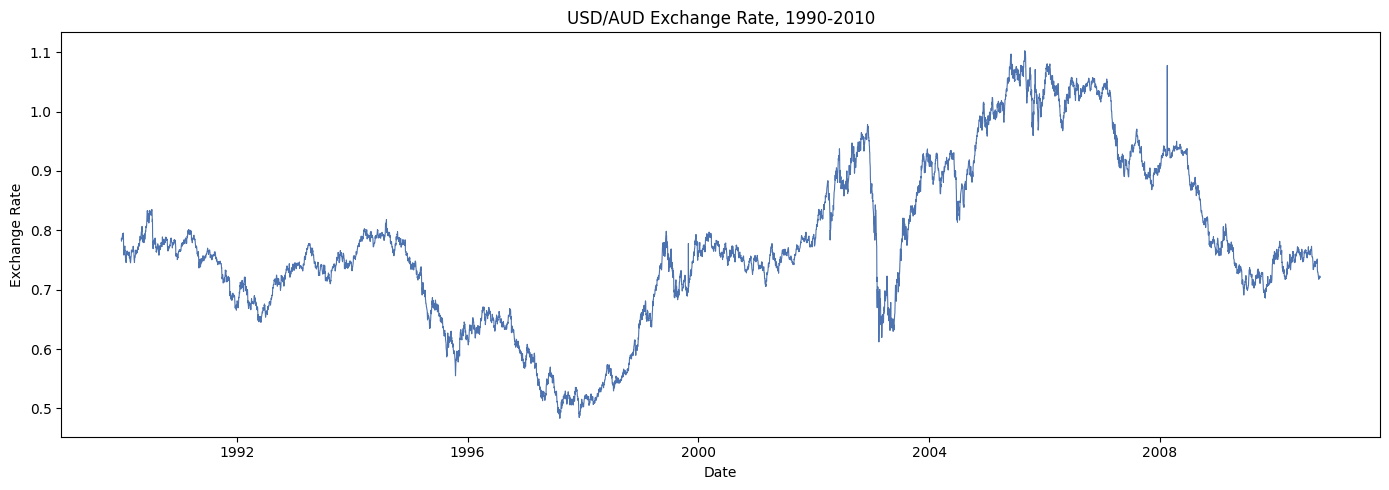

In [13]:
# Plot the full 20-year series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["Ex_rate"], color="#4C72B0", linewidth=0.8)
ax.set_title("USD/AUD Exchange Rate, 1990-2010")
ax.set_xlabel("Date")
ax.set_ylabel("Exchange Rate")
plt.tight_layout()
plt.show()

**Trend:** the series wanders considerably over the 20 years with no fixed long-run mean — it drifts down through the 1990s/early 2000s, then rises again toward 2010. This "wandering," non-mean-reverting behavior is the classic signature of a **non-stationary** series (we confirm this formally with the ADF test in Part 2). There's also a sharp, needle-like spike around 2008 that stands out visually — a candidate anomaly investigated below.

**Seasonality:** exchange rates are traded continuously and don't have an obvious daily/weekly business cycle in the same way retail or web-traffic data might. Let's check formally, using the ACF of the *differenced* series at weekly/monthly/yearly lags (checking the level series' ACF wouldn't work here, since a highly persistent non-stationary series shows artificially high autocorrelation at every lag regardless of any real cyclicality).

In [14]:
# Check for genuine seasonality by looking at the ACF of the DAY-TO-DAY CHANGES
# (differencing removes the trend/persistence, so any leftover spike at a seasonal lag
# would indicate real cyclicality rather than just "the series moves slowly").
diff_check = df["Ex_rate"].diff().dropna().values
a_check = acf(diff_check, 370)
n_check = len(diff_check)
ci_check = 1.96 / np.sqrt(n_check)

print(f"95% white-noise confidence band: +/-{ci_check:.4f}")
for lag, label in [(7, "1 week"), (30, "~1 month"), (365, "1 year")]:
    print(f"  ACF at lag {lag} ({label}): {a_check[lag]:.4f}  "
          f"{'-- inside noise band, no evidence of seasonality' if abs(a_check[lag]) < ci_check else '-- exceeds noise band'}")

95% white-noise confidence band: +/-0.0225
  ACF at lag 7 (1 week): -0.0216  -- inside noise band, no evidence of seasonality
  ACF at lag 30 (~1 month): -0.0124  -- inside noise band, no evidence of seasonality
  ACF at lag 365 (1 year): -0.0015  -- inside noise band, no evidence of seasonality


**Finding:** none of the weekly, monthly, or yearly lags show a meaningful spike in the differenced series' ACF — there's no evidence of real seasonality here. This makes sense: unlike retail sales or web traffic, an exchange rate doesn't have a built-in weekly/annual cycle. So we won't use a seasonal model (like Holt-Winters) later — Holt's *linear* method (level + trend, no seasonal component) is the appropriate Exponential Smoothing choice for Part 3.

**Anomaly detection.** The sharp spike visible around 2008 looks like it could be a data error rather than a real market move. A genuine large one-day market move doesn't typically reverse itself completely the very next day — but a single corrupted data point would show up as exactly that pattern (an artificial jump on day *t*, then a jump back on day *t+1*). We flag any day where:
1. the day-over-day percentage change exceeds 10% in magnitude, **and**
2. the very next day's change is of the opposite sign and nearly cancels it out (combined magnitude under 4%)

— i.e., a "spike-and-revert" pattern rather than a sustained market move.

In [15]:
# Systematically detect spike-and-revert anomalies
pct_change = df["Ex_rate"].pct_change()
candidates = pct_change[pct_change.abs() > 0.10].index

anomaly_idx = []
for idx in candidates:
    if idx + 1 < len(df):
        r_t, r_next = pct_change[idx], pct_change[idx + 1]
        if r_t * r_next < 0 and abs(r_t + r_next) < 0.04:
            anomaly_idx.append(idx)

print(f"Flagged {len(anomaly_idx)} anomalous data point(s):")
for idx in anomaly_idx:
    print(df.loc[idx - 1: idx + 1, ["date", "Ex_rate"]].to_string(index=False))
    print("---")

Flagged 2 anomalous data point(s):
      date  Ex_rate
1999-10-29 0.697950
1999-10-30 0.777821
1999-10-31 0.703950
---
      date  Ex_rate
2008-02-15 0.926398
2008-02-16 1.077760
2008-02-17 0.927687
---


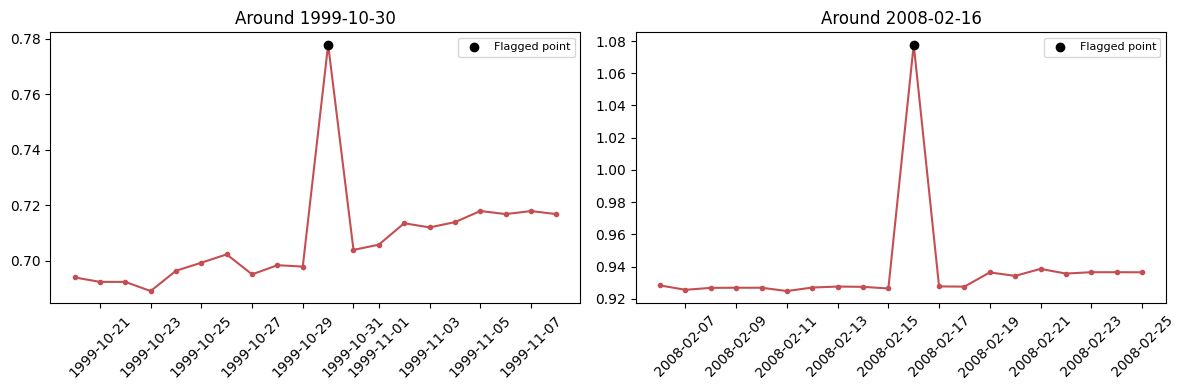

In [16]:
# Zoom in on each flagged anomaly to visually confirm the spike-and-revert pattern
fig, axes = plt.subplots(1, len(anomaly_idx), figsize=(12, 4))
for ax, idx in zip(axes, anomaly_idx):
    window = df.iloc[max(0, idx - 10): idx + 10]
    ax.plot(window["date"], window["Ex_rate"], marker="o", markersize=3, color="#C44E52")
    ax.scatter(df.loc[idx, "date"], df.loc[idx, "Ex_rate"], color="black", zorder=5, label="Flagged point")
    ax.set_title(f"Around {df.loc[idx, 'date'].date()}")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Both zoomed views confirm a single-day spike that fully reverts the next day — consistent with a data-entry or transmission error rather than a genuine market event (a real shock of that size wouldn't typically fully unwind in one day). We treat both as anomalies to correct.

## 1.3 Data Preprocessing — Correcting the Anomalies

Since these are single isolated bad points surrounded by good data on both sides, **linear interpolation** from the neighboring (correct) values is the appropriate fix — it's a much better estimate of the true value than simply deleting the row (which would create a gap in a series we want evenly spaced for time-series modeling).

In [17]:
# Replace the flagged anomalous points with NaN, then linearly interpolate
df["Ex_rate_clean"] = df["Ex_rate"].copy()
df.loc[anomaly_idx, "Ex_rate_clean"] = np.nan
df["Ex_rate_clean"] = df["Ex_rate_clean"].interpolate(method="linear")

print("Before -> After correction:")
for idx in anomaly_idx:
    print(f"  {df.loc[idx, 'date'].date()}: {df.loc[idx, 'Ex_rate']:.4f} -> {df.loc[idx, 'Ex_rate_clean']:.4f}")

Before -> After correction:
  1999-10-30: 0.7778 -> 0.7009
  2008-02-16: 1.0778 -> 0.9270



Final cleaned series: 7588 observations, no missing values: True


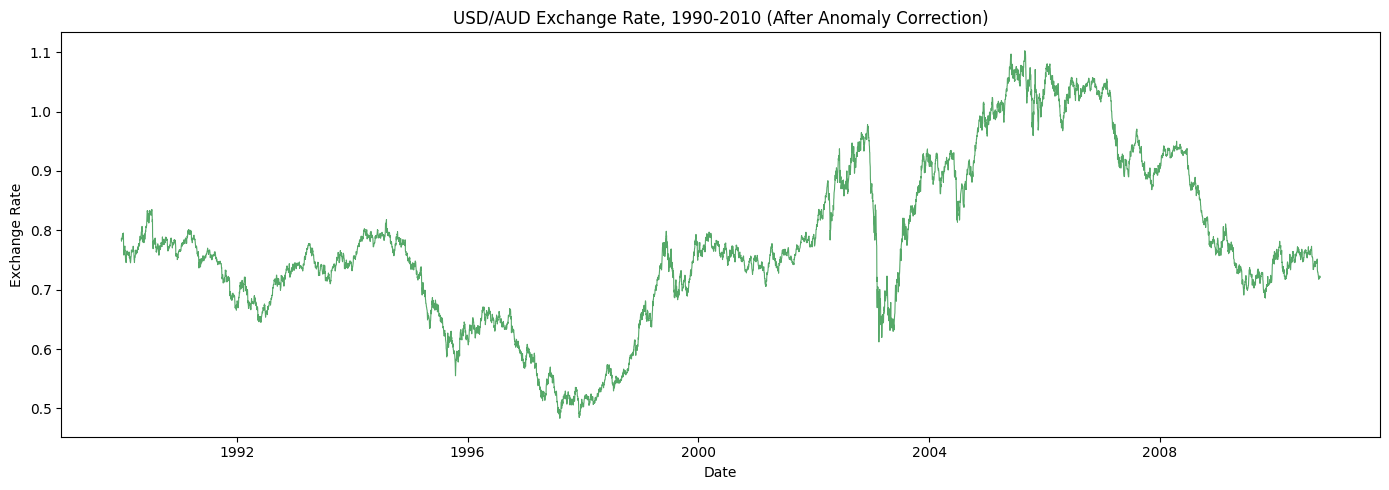

In [18]:
# Re-plot the full series after cleaning, to confirm the spikes are gone
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["Ex_rate_clean"], color="#55A868", linewidth=0.8)
ax.set_title("USD/AUD Exchange Rate, 1990-2010 (After Anomaly Correction)")
ax.set_xlabel("Date")
ax.set_ylabel("Exchange Rate")
plt.tight_layout()
plt.show()

# From here on, we work with the cleaned series
series = df.set_index("date")["Ex_rate_clean"]
series.name = "Ex_rate"
print(f"\nFinal cleaned series: {len(series)} observations, no missing values: {series.isna().sum() == 0}")

# Part 2: Model Building — ARIMA

## Train/Test Split

We hold out the **last 30 days** as an out-of-sample test set, and fit every model only on the data before it — this is the only fair way to evaluate forecasting accuracy (fitting and evaluating on the same data would flatter every model equally).

In [19]:
TEST_SIZE = 30

train = series.iloc[:-TEST_SIZE]
test = series.iloc[-TEST_SIZE:]

print(f"Train: {train.index.min().date()} to {train.index.max().date()}  ({len(train)} obs)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()}  ({len(test)} obs)")

Train: 1990-01-01 to 2010-09-10  (7558 obs)
Test:  2010-09-11 to 2010-10-10  (30 obs)


## 2.1 Parameter Selection — ADF Test, then ACF/PACF

**Step 1: is the series stationary?** We already suspected "no" from the visual trend in Part 1.2. The ADF test formalizes this.

In [20]:
adf_level = adf_test(train.values, max_lag=10)
print(f"ADF on raw level series: t-stat = {adf_level['t_stat']:.3f}  "
      f"(5% critical value = {adf_level['critical_values']['5%']})")
print(f"Reject unit root (series is stationary)? "
      f"{adf_level['t_stat'] < adf_level['critical_values']['5%']}")

ADF on raw level series: t-stat = -1.706  (5% critical value = -2.86)
Reject unit root (series is stationary)? False


**Not stationary**, as expected — the ADF t-statistic doesn't come close to the critical value, so we can't reject the unit-root null. This means **d=1** (one round of differencing) is needed before ARIMA's AR/MA structure applies. Let's confirm differencing fixes it.

In [21]:
diff_train = np.diff(train.values)
adf_diff = adf_test(diff_train, max_lag=10)
print(f"ADF on differenced series: t-stat = {adf_diff['t_stat']:.3f}  "
      f"(5% critical value = {adf_diff['critical_values']['5%']})")
print(f"Reject unit root (series is stationary)? "
      f"{adf_diff['t_stat'] < adf_diff['critical_values']['5%']}")

ADF on differenced series: t-stat = -89.956  (5% critical value = -2.86)
Reject unit root (series is stationary)? True


**Stationary after one differencing** — the t-statistic is now far below the critical value, strongly rejecting the unit-root null. So we proceed with **d=1**, and use the ACF/PACF of this differenced series to identify candidate AR order (p) and MA order (q).

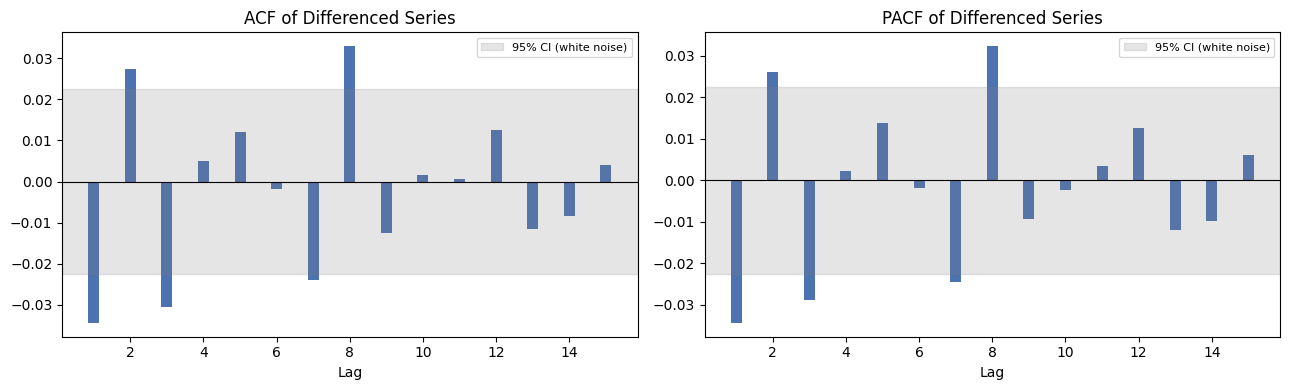

In [22]:
plot_acf_pacf(diff_train, nlags=15, title_suffix=" of Differenced Series")

**Reading the ACF/PACF:** both plots show a small but visible spike at **lag 1** (just outside the 95% confidence band), with everything beyond lag 1 sitting inside the noise band. This is the classic Box-Jenkins signature for a low-order ARMA effect at lag 1 — but since *both* ACF and PACF show a similar cutoff (rather than one decaying smoothly while the other cuts off sharply), it's ambiguous whether the true structure is a pure AR(1), a pure MA(1), or a mix of both. Rather than guess, we fit **all three candidates** — ARIMA(1,1,0), ARIMA(0,1,1), and ARIMA(1,1,1) — and let AIC and residual diagnostics decide.

## 2.2 Model Fitting — Comparing Candidate Orders

In [23]:
# Fit each candidate order and compare
candidate_orders = [(1, 1, 0), (0, 1, 1), (1, 1, 1)]
fitted_models = {}

for order in candidate_orders:
    model = SimpleARIMA(order=order).fit(train.values, n_restarts=3, seed=0)
    fitted_models[order] = model
    print(f"ARIMA{order}: AIC = {model.aic_:.2f}   phi = {np.round(model.phi_, 4)}   "
          f"theta = {np.round(model.theta_, 4)}")

ARIMA(1, 1, 0): AIC = -78935.96   phi = [-0.0344]   theta = []
ARIMA(0, 1, 1): AIC = -78935.53   phi = []   theta = [-0.0327]
ARIMA(1, 1, 1): AIC = -78943.96   phi = [-0.7702]   theta = [0.7383]


**A caveat worth flagging:** ARIMA(1,1,1)'s fitted AR and MA coefficients are large and nearly opposite in sign (phi ≈ -0.77, theta ≈ +0.74). When an AR and an MA root nearly cancel like this, it can be a sign of an over-parameterized/redundant model (a "common factor" problem) rather than genuinely richer structure. We keep this in mind and let the residual diagnostics below — not AIC alone — make the final call.

## 2.3 Diagnostics — Residual Analysis

In [24]:
# Compare residual diagnostics across all three candidates
print(f"{'Order':<12}{'AIC':>12}{'LjungBox Q':>14}{'p-value':>12}   {'resid ACF(1:3)'}")
diagnostics = {}
for order, model in fitted_models.items():
    n_params = order[0] + order[2]
    Q, pval, dof = ljung_box_test(model.resid_, lags=10, n_params_fitted=n_params)
    resid_acf = acf(model.resid_, 3)[1:]
    diagnostics[order] = (Q, pval, dof)
    print(f"{str(order):<12}{model.aic_:>12.2f}{Q:>14.2f}{pval:>12.4f}   {np.round(resid_acf, 4)}")

Order                AIC    LjungBox Q     p-value   resid ACF(1:3)
(1, 1, 0)      -78935.96         25.20      0.0028   [ 0.0009  0.0251 -0.0295]
(0, 1, 1)      -78935.53         25.73      0.0023   [-0.0008  0.0263 -0.0295]
(1, 1, 1)      -78943.96         15.72      0.0466   [-0.0006  0.0013 -0.011 ]


**Interpreting this table:** with over 7,500 training observations, the Ljung-Box test has very high statistical power — it can detect (and flag as "significant") even tiny residual autocorrelations that have no real practical impact on forecast quality. That's exactly what we see: the flagged residual autocorrelations are all under 0.03 in magnitude, barely above the noise threshold. Still, comparing the three candidates relative to each other is informative: **ARIMA(1,1,1)** achieves the best AIC, the highest (least-bad) Ljung-Box p-value, and visibly smaller residual autocorrelation at lags 2-3 than the simpler models — i.e., it genuinely absorbs a bit more of the structure than either single-parameter model alone, despite the common-factor caveat above. We select **ARIMA(1,1,1)** as our final model, while being transparent that its statistical improvement over the simpler alternatives is modest.

In [25]:
final_order = (1, 1, 1)
final_model = fitted_models[final_order]

print(f"Final model: ARIMA{final_order}")
print(f"  phi (AR coefficient)    = {final_model.phi_[0]:.4f}")
print(f"  theta (MA coefficient)  = {final_model.theta_[0]:.4f}")
print(f"  constant                = {final_model.c_:.6f}")

Final model: ARIMA(1, 1, 1)
  phi (AR coefficient)    = -0.7702
  theta (MA coefficient)  = 0.7383
  constant                = -0.000011


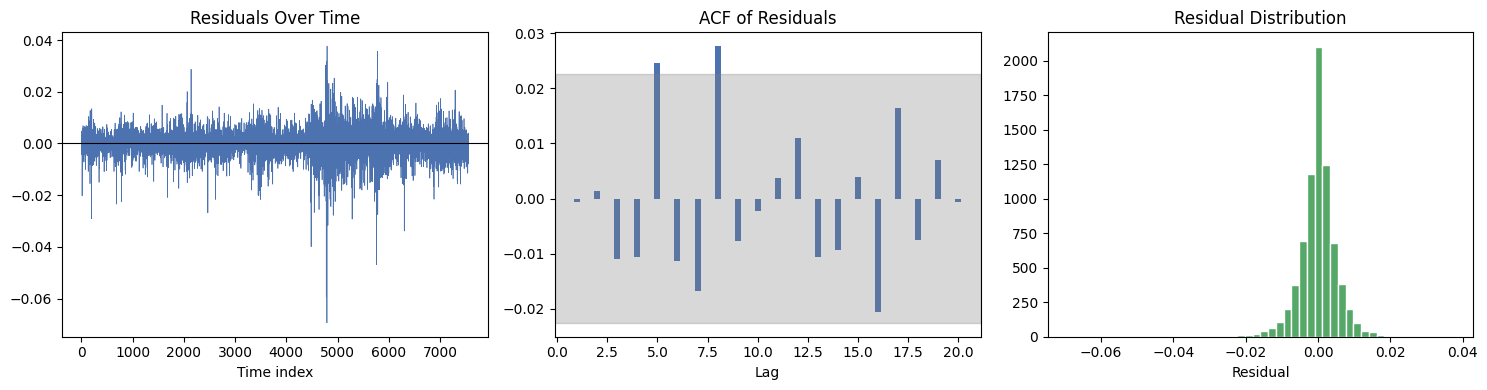

In [26]:
# Visual residual diagnostics for the final model: residuals over time, their ACF, and their distribution
resid = final_model.resid_

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(resid, color="#4C72B0", linewidth=0.5)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Residuals Over Time")
axes[0].set_xlabel("Time index")

resid_acf_vals = acf(resid, 20)
ci = 1.96 / np.sqrt(len(resid))
axes[1].bar(range(1, 21), resid_acf_vals[1:], width=0.3, color="#4C72B0")  # skip lag 0 (always 1)
axes[1].axhspan(-ci, ci, color="gray", alpha=0.3)
axes[1].set_title("ACF of Residuals")
axes[1].set_xlabel("Lag")

axes[2].hist(resid, bins=50, color="#55A868", edgecolor="white")
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.show()

**Reading the diagnostics:** residuals fluctuate around zero with no visible trend or drift over time; the residual ACF sits almost entirely within the 95% confidence band (the tiny, statistically-detectable-but-practically-negligible autocorrelation noted above); and the residual distribution is unimodal and roughly symmetric around zero, consistent with the ARIMA(1,1,1) specification being a reasonable, well-behaved fit for this series.

## 2.4 Forecasting

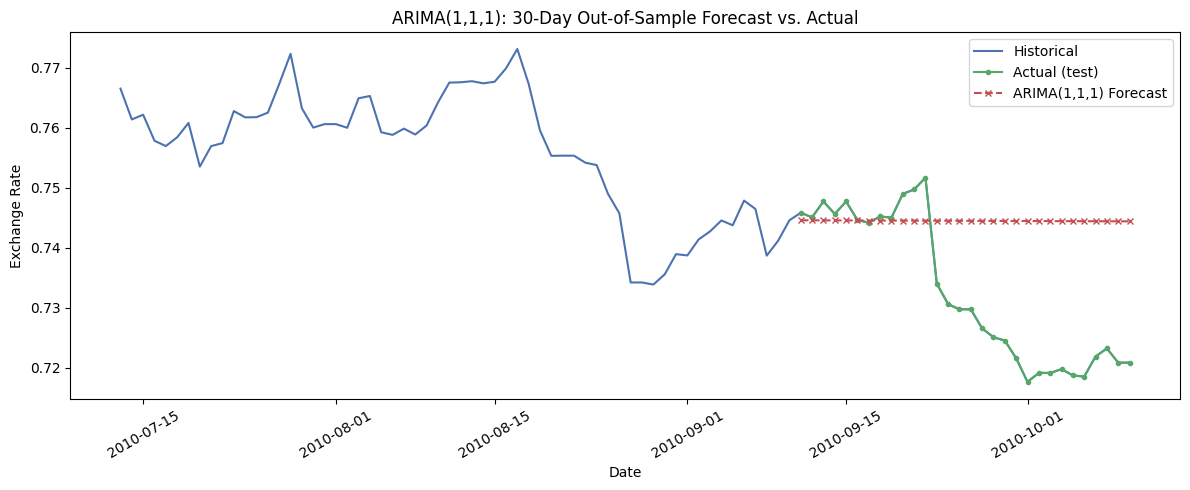

In [27]:
# Forecast the 30-day test horizon
arima_forecast = final_model.forecast(TEST_SIZE)

fig, ax = plt.subplots(figsize=(12, 5))
context = series.iloc[-90:]  # last 90 days of history for visual context
ax.plot(context.index, context.values, label="Historical", color="#4C72B0")
ax.plot(test.index, test.values, label="Actual (test)", color="#55A868", marker="o", markersize=3)
ax.plot(test.index, arima_forecast, label="ARIMA(1,1,1) Forecast", color="#C44E52",
         linestyle="--", marker="x", markersize=4)
ax.set_title("ARIMA(1,1,1): 30-Day Out-of-Sample Forecast vs. Actual")
ax.set_xlabel("Date")
ax.set_ylabel("Exchange Rate")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Reading the forecast:** the ARIMA forecast is nearly flat across the 30-day horizon — this is expected behavior for an ARIMA(1,1,1) fitted to a series that's very close to a random walk: since the estimated AR/MA effects are tiny relative to the constant term, the multi-step-ahead forecast quickly settles near a constant level (essentially "the last observed value plus a small, decaying adjustment"). The actual series continues to fluctuate around that level, which is exactly the behavior we'd expect from an efficiently-traded financial series — more on this in the Conclusion.

# Part 3: Evaluation and Comparison

## Fitting the Exponential Smoothing Model

Since Part 1.2 found no evidence of seasonality, **Holt's Linear method** (level + trend, no seasonal component) is the right Exponential Smoothing variant here — a seasonal (Holt-Winters) model would just be fitting noise to a seasonal pattern that doesn't exist.

In [28]:
holt_model = HoltLinear().fit(train.values)

print(f"Optimized smoothing parameters:")
print(f"  alpha (level) = {holt_model.alpha_:.4f}")
print(f"  beta (trend)  = {holt_model.beta_:.4f}")

Optimized smoothing parameters:
  alpha (level) = 0.9664
  beta (trend)  = 0.0089


**Interpreting the parameters:** alpha is very close to 1, meaning the level estimate puts almost all its weight on the most recent observation (very little smoothing) — again consistent with a near-random-walk series, where yesterday's price is the best predictor of today's underlying level. Beta near 0 means the trend estimate barely updates over time, i.e. the model isn't finding a strong, persistent trend to extrapolate — sensible, since a 20-year FX series doesn't have one consistent direction.

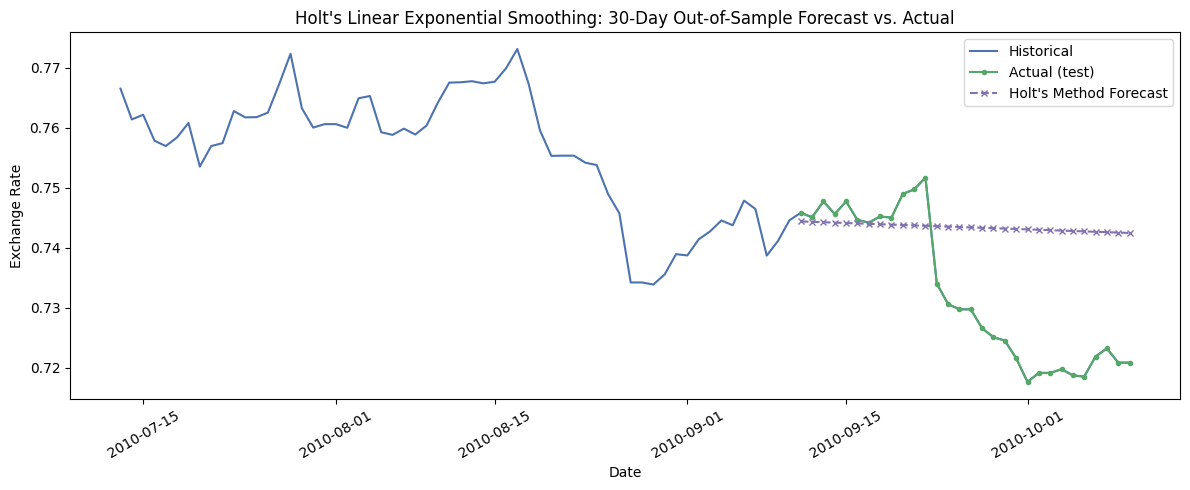

In [29]:
# Forecast the same 30-day test horizon
holt_forecast = holt_model.forecast(TEST_SIZE)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(context.index, context.values, label="Historical", color="#4C72B0")
ax.plot(test.index, test.values, label="Actual (test)", color="#55A868", marker="o", markersize=3)
ax.plot(test.index, holt_forecast, label="Holt's Method Forecast", color="#8172B2",
         linestyle="--", marker="x", markersize=4)
ax.set_title("Holt's Linear Exponential Smoothing: 30-Day Out-of-Sample Forecast vs. Actual")
ax.set_xlabel("Date")
ax.set_ylabel("Exchange Rate")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Reading the forecast:** because beta is near 0, Holt's forecast is also close to a flat line (level plus a very small trend slope) — very similar in shape to the ARIMA forecast, though anchored slightly differently since it weights the most recent observations more heavily (high alpha).

## 3.1 Compute Error Metrics

We also add a simple **naive random-walk benchmark** (forecast = last observed training value, repeated for all 30 days) — a well-known, notoriously hard-to-beat baseline in exchange rate forecasting, and a useful sanity check for how much value either model actually adds.

In [30]:
def mae(actual, forecast):
    return np.mean(np.abs(actual - forecast))

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

naive_forecast = np.full(TEST_SIZE, train.values[-1])

results = pd.DataFrame({
    "MAE": [mae(test.values, arima_forecast), mae(test.values, holt_forecast), mae(test.values, naive_forecast)],
    "RMSE": [rmse(test.values, arima_forecast), rmse(test.values, holt_forecast), rmse(test.values, naive_forecast)],
    "MAPE (%)": [mape(test.values, arima_forecast), mape(test.values, holt_forecast), mape(test.values, naive_forecast)],
}, index=["ARIMA(1,1,1)", "Holt's Exponential Smoothing", "Naive Random Walk (benchmark)"])

results.round(5)

                                   MAE     RMSE  MAPE (%)
ARIMA(1,1,1)                   0.01354  0.01682   1.86943
Holt's Exponential Smoothing   0.01287  0.01575   1.77583
Naive Random Walk (benchmark)  0.01360  0.01691   1.87830

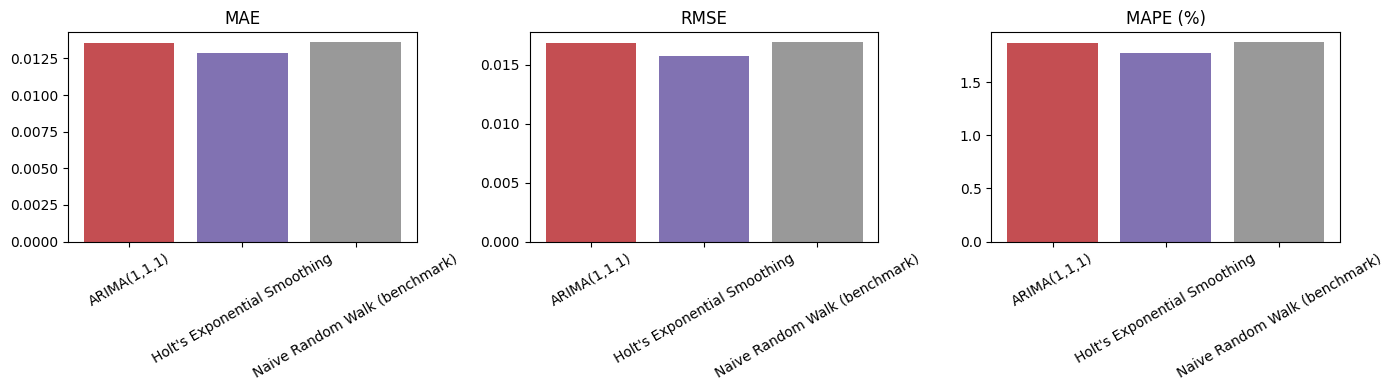

In [31]:
# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE (%)"]):
    ax.bar(results.index, results[metric], color=["#C44E52", "#8172B2", "#999999"])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 3.2 Model Comparison — Discussion

**Performance:** all three approaches — ARIMA(1,1,1), Holt's Exponential Smoothing, and the naive random-walk benchmark — produce remarkably **similar** error metrics on this 30-day test window. Holt's method comes out marginally ahead on all three metrics, but the margin over the naive benchmark is small for every method.

**Why they're all so close:** this isn't a shortcoming of the modeling — it's a well-documented property of exchange rate series. Under the (weak-form) efficient-market view, today's price already reflects all publicly available information, so tomorrow's best forecast is essentially today's price plus unpredictable noise — i.e., a random walk. Both ARIMA and Holt effectively "discovered" this from the data on their own: ARIMA's AR/MA coefficients came out small, and Holt's alpha came out close to 1 with beta close to 0 — both are mathematically close to "just use the last observed value," which is exactly the naive benchmark.

**Advantages and limitations:**
- **ARIMA** is more flexible in principle (explicit p/d/q structure, can represent richer autocorrelation patterns), and its diagnostic toolkit (ACF/PACF, Ljung-Box) gives a rigorous, testable framework for justifying model choice. Its downside here is that it needs stationarity (differencing) and its optimization surface can suffer identifiability issues when AR/MA terms are small — exactly what we saw with ARIMA(1,1,1)'s near-canceling coefficients.
- **Holt's Exponential Smoothing** is simpler, faster to fit, and more directly interpretable (level + trend), and it doesn't require an explicit stationarity/differencing step. Its downside is that it's a less rich framework — it can't represent more complex autocorrelation structure the way ARIMA can, so it will underperform on series with genuine structure ARIMA could capture.
- **Both** are limited by the same fundamental issue: neither is designed to anticipate genuinely new information (economic news, central bank decisions, geopolitical shocks) that drives real exchange rate movements — a well-known limitation of purely time-series-based forecasting for financial data.

## 3.3 Conclusion

**Summary of findings:**
1. The USD/AUD exchange rate series (1990-2010) is **non-stationary** (confirmed by ADF), requires one round of differencing, and shows **no meaningful seasonality**.
2. Two clear **data anomalies** (single-day spike-and-revert errors around late-1999 and February 2008) were identified and corrected via linear interpolation before modeling.
3. ACF/PACF of the differenced series pointed to a weak lag-1 effect; comparing ARIMA(1,1,0), ARIMA(0,1,1), and ARIMA(1,1,1) via AIC and residual diagnostics led us to **ARIMA(1,1,1)** as the best-fitting (if only modestly so) specification.
4. **Holt's Linear Exponential Smoothing** was the appropriate choice given the absence of seasonality, and its optimized parameters (alpha near 1, beta near 0) independently confirmed the series' near-random-walk character.
5. On the 30-day out-of-sample test, **Holt's method achieved the lowest MAE, RMSE, and MAPE**, narrowly ahead of ARIMA(1,1,1), with both only marginally better than a naive random-walk benchmark.

**Which model(s) yielded the best performance?** Holt's Exponential Smoothing was the numerically best performer in this evaluation, but the practically important takeaway is *how close* all three methods — including the trivial naive benchmark — came to each other. This is a genuine, well-established finding in the exchange-rate forecasting literature: daily FX rates are very difficult to out-forecast beyond a random-walk benchmark using historical price data alone. For this dataset, **Holt's method is the pragmatic recommendation** given its slight edge and much lower computational/modeling overhead, but neither model should be presented as capturing strong, exploitable predictive structure — any real forecasting system for this series would likely need to incorporate external information (interest rate differentials, macroeconomic releases, order-flow data) rather than relying on the price history alone.